In [10]:
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.data import random_split

from torchvision import datasets
import torchvision.transforms as transforms

import torch.optim as optim

import matplotlib.pyplot as plt

In [2]:
batch_size = 128

Loads the test_val_datset, and the test_dataset. This will take a couple of minutes to load

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

training_data = datasets.CIFAR10(
    root= "data", 
    train = True,
    download=True,
    transform=transform
)

testing_data = datasets.CIFAR10(
    root= "data", 
    train = False,
    download=True,
    transform=transform
)



In [4]:
train_val_amt = int(len(training_data) * 0.75)
validation_set = int(len(training_data) - train_val_amt)

print(train_val_amt, validation_set)

train_dataset, validation_dataset = random_split(training_data, [train_val_amt, validation_set], generator=torch.Generator().manual_seed(1234))

37500 12500


In [5]:
train_data_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
testing_data_loader = DataLoader(testing_data, batch_size = batch_size, shuffle = True)

Prints the dataset numbers and percentage of training and validation data.

In [6]:
print(f"Training Data Total: {len(train_dataset)}, {len(train_dataset) / (len(train_dataset) + len(validation_dataset))}")
print(f"Validation Data Total: {len(validation_dataset)}, {len(validation_dataset) / (len(train_dataset) + len(validation_dataset))}")
print(f"Testing Data total:", len(testing_data))


Training Data Total: 37500, 0.75
Validation Data Total: 12500, 0.25
Testing Data total: 10000


tensor([[[0.6118, 0.8157, 1.0000],
         [0.6078, 0.8078, 0.9843],
         [0.6157, 0.8157, 0.9882],
         ...,
         [0.5882, 0.7804, 0.9843],
         [0.5765, 0.7725, 0.9843],
         [0.5647, 0.7647, 0.9882]],

        [[0.6275, 0.8353, 1.0000],
         [0.6196, 0.8235, 1.0000],
         [0.6235, 0.8275, 1.0000],
         ...,
         [0.5882, 0.7882, 1.0000],
         [0.5765, 0.7804, 0.9961],
         [0.5725, 0.7765, 1.0000]],

        [[0.6275, 0.8314, 1.0000],
         [0.6157, 0.8196, 0.9961],
         [0.6196, 0.8235, 1.0000],
         ...,
         [0.5725, 0.7843, 0.9961],
         [0.5686, 0.7765, 0.9961],
         [0.5647, 0.7686, 0.9961]],

        ...,

        [[0.5765, 0.7843, 1.0000],
         [0.5686, 0.7725, 0.9922],
         [0.5725, 0.7725, 0.9961],
         ...,
         [0.5294, 0.7686, 0.9922],
         [0.5294, 0.7686, 0.9922],
         [0.5255, 0.7608, 0.9961]],

        [[0.5843, 0.7922, 1.0000],
         [0.5725, 0.7765, 1.0000],
         [0.

Text(0.5, 1.0, 'Airplane')

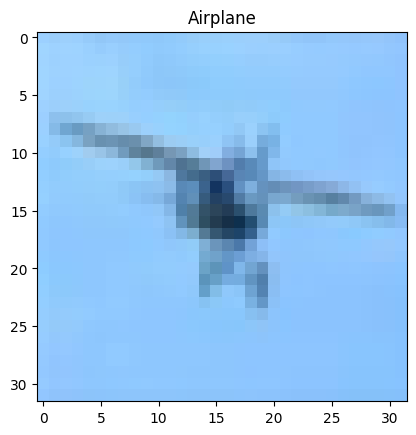

In [7]:
classes = ["Airplane", "Automobile", "Bird", "Cat", "Deer", "Dog", "Frog", "Horse", "Ship", "Truck"]
training_iter = iter(train_data_loader)

data_obj, label = next(training_iter)
data_obj = data_obj[0]
data_obj = data_obj * 0.5 + 0.5
label = label[0]
data_obj = data_obj.permute(1, 2, 0)
print(data_obj, label)
plt.imshow(data_obj)
plt.title(f"{classes[label]}")

In [14]:
class ConvNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        #Input is 32 x 32 pixels, 3 channels
        self.conv1Net = nn.Conv2d(3, 3, 5)
        # Output is 3, 28 x 28 matrices
        self.maxPool2D1 = nn.MaxPool2d(2,2)
        # Output is 3, 14 x 14 matrices
        self.conv2Net = nn.Conv2d(3, 18, 3)
        # Output is 18, 12 x 12 matrices
        self.maxPool2D2 = nn.MaxPool2d(2,2)
        # Output is 18, 6 x 6 matrices
        self.lin = nn.Linear(18 * 6 * 6, 10)

    def forward(self, x):
        x = self.maxPool2D1(F.relu(self.conv1Net(x)))
        x = self.maxPool2D2(F.relu(self.conv2Net(x)))
        x = self.lin(torch.flatten(x, 1))
        return x



In [15]:
CNN = ConvNeuralNetwork()

criteriorn = nn.CrossEntropyLoss()
optimizer = optim.SGD(CNN.parameters(), lr = 0.001)

In [17]:
max_epoch = 2

for epoch in range(max_epoch):
    run_loss = 0
    for data in train_data_loader:
        inputs, labels = data

        optimizer.zero_grad()

        output = CNN(inputs)
        loss = criteriorn(output, labels)
        loss.backward()
        optimizer.step()

        run_loss += loss.item()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.92941177..0.9372549].


tensor([9])
tensor([[[0.6118, 0.8157, 1.0000],
         [0.6078, 0.8078, 0.9843],
         [0.6157, 0.8157, 0.9882],
         ...,
         [0.5882, 0.7804, 0.9843],
         [0.5765, 0.7725, 0.9843],
         [0.5647, 0.7647, 0.9882]],

        [[0.6275, 0.8353, 1.0000],
         [0.6196, 0.8235, 1.0000],
         [0.6235, 0.8275, 1.0000],
         ...,
         [0.5882, 0.7882, 1.0000],
         [0.5765, 0.7804, 0.9961],
         [0.5725, 0.7765, 1.0000]],

        [[0.6275, 0.8314, 1.0000],
         [0.6157, 0.8196, 0.9961],
         [0.6196, 0.8235, 1.0000],
         ...,
         [0.5725, 0.7843, 0.9961],
         [0.5686, 0.7765, 0.9961],
         [0.5647, 0.7686, 0.9961]],

        ...,

        [[0.5765, 0.7843, 1.0000],
         [0.5686, 0.7725, 0.9922],
         [0.5725, 0.7725, 0.9961],
         ...,
         [0.5294, 0.7686, 0.9922],
         [0.5294, 0.7686, 0.9922],
         [0.5255, 0.7608, 0.9961]],

        [[0.5843, 0.7922, 1.0000],
         [0.5725, 0.7765, 1.0000],


Text(0.5, 1.0, 'Actual: Truck Predicted: Truck')

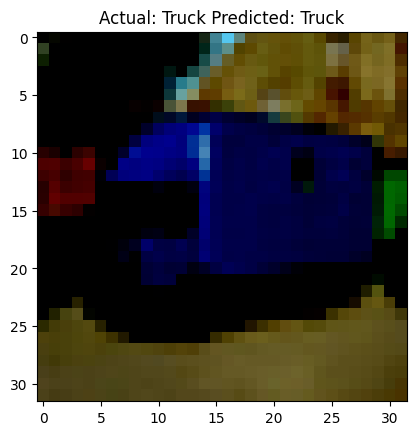

In [36]:
testing_iter = iter(testing_data_loader)

data_obj_te, label_te = next(testing_iter)
data_obj_te = data_obj_te[0]

data_obj_unorm = data_obj_te * 0.5 + 0.5
label_te = label_te[0]
data_obj_im = data_obj_te.permute(1, 2, 0)

output = CNN(data_obj_te.unsqueeze(0))
_, predicted = torch.max(output.data, 1)

print(predicted)
print(data_obj, label)
plt.imshow(data_obj_im)
plt.title(f"Actual: {classes[label_te]} Predicted: {classes[predicted]}")
